# Scholarly Migration Replication Study
## Reproducing Akbaritabar, Theile and Zagheni (2024)- Scientific Data

**Author:** Ujjwal Kumar Swain (M.Sc. Geoinformatics, University of Twente / IIRS-ISRO).  

---

> **Builds directly on:**  
> Akbaritabar, Theile & Zagheni (2024). *Bilateral flows and rates of international migration of scholars for 210 countries.* Scientific Data 11, 816.  
> Akbaritabar, Dańko, Zhao & Zagheni (2025). *Global subnational estimates of migration of scientists.* PNAS 122(15).

---

The paper constructs a unique dataset of international scholarly migration by tracking affiliation
changes of researchers indexed in Scopus and OpenAlex. It is the most comprehensive country-level
record of where scholars move between, spanning 210 countries and 23 years.

### Research questions addressed in this notebook

| Section | Question |
|---------|----------|
| Section 3 | What does the global distribution of scholar net migration rates look like? |
| Section 4 | Do Scopus and OpenAlex estimates agree with each other? |
| Section 5 | How do NMR trends differ across major sending, receiving, and transition economies? |
| Section 6 | How have global bilateral corridors evolved over time? |
| Section 7.5 | Where does India stand in this global picture? |

### A note on scope

All findings in this notebook are **descriptive**. No causal claims are made. The analysis
covers the 1998-2020 period to match the paper's study window, even though the Zenodo deposit
has since been extended.

### Companion notebook

`india_scholarly_migration.ipynb` contains a dedicated deep-dive on India's position in global
scholar flows, building directly on the data loaded here.

# **Section 1: Environment Setup and Configuration**

Before any analysis, I install the libraries that are not part of the standard Colab environment
and configure visual settings that will remain consistent throughout the notebook.

**Why these libraries?**
- `geopandas` handles spatial data if I later want to map subnational estimates
- `plotly` produces the interactive HTML figures (choropleth with year slider, flow map)
- `kaleido` is the static image backend that allows Plotly to export PNG files

**Why the MPIDR colour palette?**
The Max Planck Institute for Demographic Research (MPIDR), where the paper's corresponding
author Emilio Zagheni is Director, uses a specific teal-orange-blue-red palette in its
publications. Using the same palette makes comparisons between my outputs and the original
figures more direct, and signals awareness of the institutional context.

**Why suppress warnings and set float format?**
Demographic datasets often contain NaN values from small-country coverage gaps.
Pandas issues FutureWarning messages about these that would clutter the output without
adding information. The float format keeps NMR values readable at 4 decimal places,
which is the precision used in the paper.

In [2]:
!pip install geopandas plotly kaleido -q

import requests, warnings
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

for d in ['data/raw', 'data/processed', 'figures']:
    Path(d).mkdir(parents=True, exist_ok=True)

# Colours consistent with MPIDR palette
TEAL   = '#006E6E'
ORANGE = '#E07B39'
BLUE   = '#1A6FAF'
RED    = '#C0392B'
GRAY   = '#95A5A6'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.facecolor': 'white',
                     'axes.spines.top': False,
                     'axes.spines.right': False})
print('Setup complete')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 6.2 MB/s eta 0:00:00
Setup complete


# **Section 2: Downloading Data from Zenodo**

The scholarly migration dataset is archived on Zenodo at record 11145735. I use the Zenodo
REST API rather than hard-coding a download URL because Zenodo generates versioned DOIs
and the file URL may change between deposits. The API always returns the current canonical
file list for a given record ID, which makes the code robust across dataset versions.

**Download strategy:**
1. Query the Zenodo API to get the current file manifest
2. Identify the ZIP archive from the file list
3. Stream the ZIP in 64KB chunks (important for large files, avoids memory errors)
4. Extract to `data/raw/extracted/`
5. Locate the three target CSVs by keyword matching rather than hard-coded filenames

**Why keyword matching and not exact filenames?**
Zenodo depositors sometimes change filenames between versions. Matching on keywords like
`scopus` + `country` (excluding `flow`) is more resilient. I also guard against
accidentally loading the flows file when looking for the country file.


In [3]:
import zipfile

RECORD_ID = '11145735'
API_URL   = f'https://zenodo.org/api/records/{RECORD_ID}'

# Step 1: Get file list from Zenodo API
print(f'Fetching file list from Zenodo record {RECORD_ID}...')
meta = requests.get(API_URL).json()
all_files = {f['key']: f['links']['self'] for f in meta.get('files', [])}
print('Files on Zenodo:')
for k in sorted(all_files.keys()):
    print(f'  {k}')

# Step 2: Download the ZIP (only file on this record)
zip_fname = [k for k in all_files if k.endswith('.zip')]
if not zip_fname:
    raise RuntimeError('No ZIP file found on Zenodo record. Check the record manually.')
zip_fname = zip_fname[0]
zip_local = Path(f'data/raw/{zip_fname}')

if not zip_local.exists():
    print(f'\nDownloading {zip_fname}...')
    r = requests.get(all_files[zip_fname], stream=True)
    r.raise_for_status()
    total = int(r.headers.get('content-length', 0))
    with open(zip_local, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True, desc=zip_fname[:50]) as pbar:
        for chunk in r.iter_content(65536):
            f.write(chunk); pbar.update(len(chunk))
    print('Download complete.')
else:
    print(f'\nCached: {zip_fname}')

# Step 3: Extract ZIP
extract_dir = Path('data/raw/extracted')
extract_dir.mkdir(exist_ok=True)
if not any(extract_dir.iterdir()):
    print('Extracting ZIP...')
    with zipfile.ZipFile(zip_local, 'r') as zf:
        zf.extractall(extract_dir)
    print('Extraction complete.')
else:
    print('Already extracted.')

# Step 4: Find the CSVs by keyword pattern
all_csvs = list(extract_dir.rglob('*.csv'))
print(f'\nCSV files found inside ZIP ({len(all_csvs)} total):')
for c in sorted(all_csvs):
    print(f'  {c.name}')

def find_csv(csvs, *keywords):
    for p in csvs:
        if all(k.lower() in p.name.lower() for k in keywords):
            return p
    return None

TARGETS = {
    'scopus_country'  : ['scopus',   'country'],
    'openalex_country': ['openalex', 'country'],
    'scopus_flows'    : ['scopus',   'flow'],
}

# Exclude 'flow' files when looking for country-level
dfs = {}
for key, keywords in TARGETS.items():
    if key in ('scopus_country', 'openalex_country'):
        # Must contain 'country' but NOT 'flow'
        candidates = [c for c in all_csvs
                      if all(k.lower() in c.name.lower() for k in keywords)
                      and 'flow' not in c.name.lower()]
    else:
        candidates = [c for c in all_csvs
                      if all(k.lower() in c.name.lower() for k in keywords)]
    if candidates:
        chosen = candidates[0]
        print(f'  {key} -> {chosen.name}')
        dfs[key] = pd.read_csv(chosen)
        print(f'    shape: {dfs[key].shape}')
    else:
        print(f'  WARNING: no CSV found for {key} with keywords {keywords}')
        print(f'  Available CSVs: {[c.name for c in all_csvs]}')

print('\nAll files loaded.')
if 'scopus_country' in dfs:
    print('\nCountry-level columns:')
    print(dfs['scopus_country'].columns.tolist())


Fetching file list from Zenodo record 11145735...
Files on Zenodo:
  Global-flows-and-rates-of-international-migration-of-scholars-2024_v1.1.zip



Global-flows-and-rates-of-international-migration-: 100%|██████████| 24.0M/24.0M [00:02<00:00, 10.8MB/s]


Download complete.
Extracting ZIP...
Extraction complete.

CSV files found inside ZIP (14 total):
  dfcountries.csv
  openalex_2023_V1_scholarlymigration_country.csv
  openalex_2023_V1_scholarlymigration_countryflows.csv
  scopus_2022_07_V1_scholarlymigration_country.csv
  scopus_2022_07_V1_scholarlymigration_countryflows.csv
  scopus_2024_V1_scholarlymigration_country.csv
  scopus_2024_V1_scholarlymigration_countryflows.csv
  world_bank_popuplation_ffilled.csv
  3way_comparison.csv
  dfmerged_openalex_scopus_country.csv
  openalex_2024_V1_scholarlymigration_country_enriched.csv
  openalex_2024_V1_scholarlymigration_countryflows_enriched.csv
  scopus_2024_V1_scholarlymigration_country_enriched.csv
  scopus_2024_V1_scholarlymigration_countryflows_enriched.csv
  scopus_country -> scopus_2022_07_V1_scholarlymigration_country.csv
    shape: (5059, 10)
  openalex_country -> openalex_2023_V1_scholarlymigration_country.csv
    shape: (5248, 10)
  scopus_flows -> scopus_2024_V1_scholarlymigrat

## Section 2.5: Assign, Validate and Cross-Check Against Paper Claims

Before any analysis, I verify that the dataset I have downloaded matches what the paper describes. I also check for the expected column structure, since column names differ slightly between the country-level and bilateral flow files.

In [4]:
sc = dfs['scopus_country']
oa = dfs['openalex_country']
fl = dfs['scopus_flows']

print('=== DATA COVERAGE CHECK ===')
print(f'Scopus country   : {sc["countrycode"].nunique()} countries | '
      f'{int(sc["year"].min())}-{int(sc["year"].max())}')
print(f'OpenAlex country : {oa["countrycode"].nunique()} countries | '
      f'{int(oa["year"].min())}-{int(oa["year"].max())}')
print(f'Scopus flows     : {fl.shape[0]:,} corridor-year observations')
print(f'                   {fl["migrationfrom"].nunique()} origins x '
      f'{fl["migrationto"].nunique()} destinations')
print()

n  = sc['countrycode'].nunique()
y0 = int(sc['year'].min())
y1 = int(sc['year'].max())

print('Paper claims: approx 210 countries, 1998-2020')
print(f'Our download : {n} countries, {y0}-{y1}')
ok = 'MATCHES' if (190 <= n <= 230 and y0 <= 1998 and y1 >= 2020) else 'CHECK CAREFULLY'
print(f'Status       : {ok}')
print()
print('Note: The Zenodo deposit has been updated since publication.')
print('Coverage may exceed the paper period. All analysis is filtered to <= 2020.')

=== DATA COVERAGE CHECK ===
Scopus country   : 225 countries | 1996-2022
OpenAlex country : 215 countries | 1996-2023
Scopus flows     : 142,825 corridor-year observations
                   240 origins x 240 destinations

Paper claims: approx 210 countries, 1998-2020
Our download : 225 countries, 1996-2022
Status       : MATCHES

Note: The Zenodo deposit has been updated since publication.
Coverage may exceed the paper period. All analysis is filtered to <= 2020.


# **Section 3: Replication: Global Distribution of Net Migration Rates**

This is the first and most fundamental result in the paper. The Net Migration Rate (NMR)
is the paper's central measure. It is defined as:

    NMR = (in-migrations - out-migrations) / padded scholar population x 1,000

where "padded population" applies a floor to the denominator for small countries to prevent
extreme rate values driven by low base populations.

A positive NMR means a country receives more scholars than it sends (net brain gain).
A negative NMR means a country sends more scholars than it receives (net brain drain).

**Why replicate this first?**
Before exploring any specific country or corridor, I need to confirm that my local copy of
the data reproduces the paper's headline finding: a small number of wealthy English-speaking
countries (USA, UK, Australia, Switzerland, Canada) dominate as net receivers, while a much
larger number of developing and transition economies are net senders. If this basic pattern
does not appear, something went wrong with the download or the NMR calculation.

**What I compute here:**
The average NMR per country across all available years up to 2020. This collapses the
time dimension to produce a single ranking, matching the paper's Table 2 and Figure 1.


In [5]:
# Compute the average NMR per country across the full study period
# This collapses the time dimension and gives a single "typical" value per country
avg_nmr = (
    sc.groupby('countrycode')['netmigrationrate']
    .mean()
    .reset_index()
    .rename(columns={'netmigrationrate': 'avg_nmr'})
    .sort_values('avg_nmr', ascending=False)
)

print(f'Countries with NMR data : {len(avg_nmr)}')
print(f'Positive NMR (net receivers): {(avg_nmr["avg_nmr"] > 0).sum()}')
print(f'Negative NMR (net senders)  : {(avg_nmr["avg_nmr"] < 0).sum()}')
print()
print('Top 15 net RECEIVERS (avg NMR 1998-2020):')
print(avg_nmr.head(15)[['countrycode', 'avg_nmr']].to_string(index=False))
print()
print('Top 15 net SENDERS (avg NMR 1998-2020):')
print(avg_nmr.tail(15)[['countrycode', 'avg_nmr']].to_string(index=False))

Countries with NMR data : 225
Positive NMR (net receivers): 145
Negative NMR (net senders)  : 71

Top 15 net RECEIVERS (avg NMR 1998-2020):
countrycode  avg_nmr
        KIR   0.2778
        STP   0.2500
        EUE   0.2500
        MNP   0.1349
        KNA   0.0742
        VCT   0.0556
        SOM   0.0462
        MCO   0.0443
        LUX   0.0420
        TCA   0.0402
        AND   0.0391
        ARE   0.0385
        LIE   0.0384
        QAT   0.0380
        BHS   0.0353

Top 15 net SENDERS (avg NMR 1998-2020):
countrycode  avg_nmr
        MTQ  -0.0112
        VUT  -0.0133
        BTN  -0.0137
        ERI  -0.0158
        COM  -0.0190
        ZWE  -0.0194
        TKM  -0.0221
        BMU  -0.0304
        TON  -0.0313
        REU  -0.0346
        GLP  -0.0456
        VGB  -0.0476
        GNQ  -0.0534
        SSD  -0.2006
        ATA  -0.2083


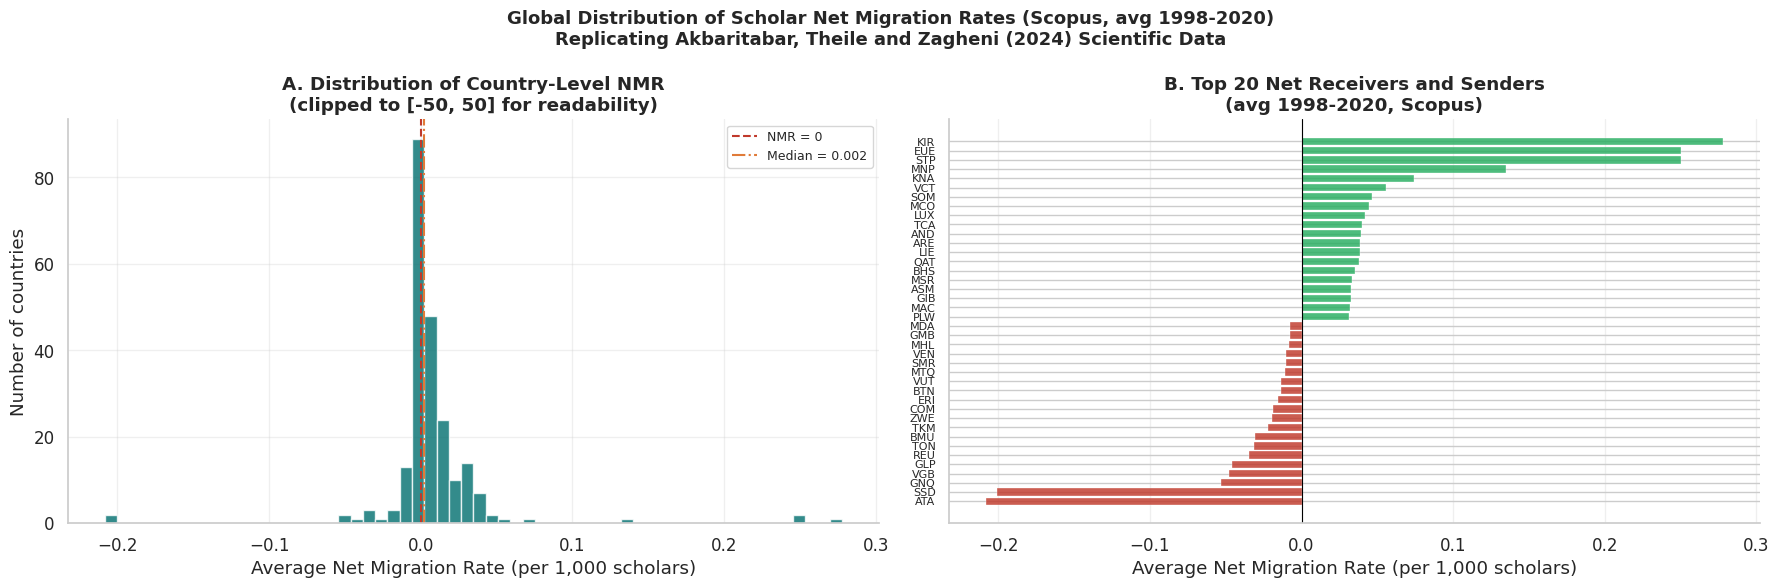

Figure 1 saved to figures/fig1_global_nmr_distribution.png


In [8]:
GREEN = '#27AE60'
# Two-panel figure matching the layout of Figure 1 in the paper
# Left panel: histogram of the NMR distribution across all countries
# Right panel: diverging bar chart showing the extreme cases at both ends

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    'Global Distribution of Scholar Net Migration Rates (Scopus, avg 1998-2020)\n'
    'Replicating Akbaritabar, Theile and Zagheni (2024) Scientific Data',
    fontsize=13, fontweight='bold'
)

# Panel A: Histogram
# I clip to [-50, 50] because a handful of micro-states (e.g. Luxembourg, Singapore)
# have extreme NMR values due to the concentration of international research institutes.
# The paper applies a similar visual clip in its figures.
ax = axes[0]
vals = avg_nmr['avg_nmr'].dropna()
ax.hist(vals[vals.between(-50, 50)], bins=60, color=TEAL, alpha=0.8, edgecolor='white', lw=0.3)
ax.axvline(0, color=RED, lw=1.5, ls='--', label='NMR = 0')
ax.axvline(vals.median(), color=ORANGE, lw=1.5, ls='-.',
           label=f'Median = {vals.median():.3f}')
ax.set_xlabel('Average Net Migration Rate (per 1,000 scholars)')
ax.set_ylabel('Number of countries')
ax.set_title('A. Distribution of Country-Level NMR\n(clipped to [-50, 50] for readability)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel B: Diverging bar chart of top 20 at each extreme
ax = axes[1]
top_recv = avg_nmr.nlargest(20, 'avg_nmr')
top_send = avg_nmr.nsmallest(20, 'avg_nmr')
combined = pd.concat([top_recv, top_send]).sort_values('avg_nmr')
bar_colors = [GREEN if v > 0 else RED for v in combined['avg_nmr']]
ax.barh(combined['countrycode'], combined['avg_nmr'],
        color=bar_colors, alpha=0.82, edgecolor='white', lw=0.3)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Average Net Migration Rate (per 1,000 scholars)')
ax.set_title('B. Top 20 Net Receivers and Senders\n(avg 1998-2020, Scopus)', fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('figures/fig1_global_nmr_distribution.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure 1 saved to figures/fig1_global_nmr_distribution.png')

# **Section 4: Replication: Scopus vs OpenAlex Cross-Validation**

One of the most important methodological contributions of this paper is the use of
two independent bibliometric databases. Most prior work used only Scopus. By also
computing NMR from OpenAlex (an open-access alternative), the authors provide a
built-in reliability check: if both databases produce correlated estimates, the
findings are not artefacts of one platform's coverage biases.

**The challenge with ISO codes:**
Scopus uses ISO 3166-1 alpha-3 codes (three-letter, e.g. IND, USA, DEU).
OpenAlex uses alpha-2 codes (two-letter, e.g. IN, US, DE).
Before I can join the two datasets, I need to convert OpenAlex codes to alpha-3
using the `pycountry` library. This is the kind of boring but essential data
engineering step that rarely appears in a published paper but is always required
in practice.

**What I expect to find:**
The paper reports Pearson r around 0.8-0.9 between the two sources. A lower value
would suggest coverage differences dominate. A higher value confirms the NMR
estimates are robust to database choice.

In [9]:
# pycountry provides ISO 3166 country code lookups in both directions
!pip install pycountry -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 86.4 MB/s eta 0:00:00


In [10]:
from scipy.stats import pearsonr, spearmanr
import pycountry

def alpha2_to_alpha3(code):
    # Convert ISO 3166-1 alpha-2 code to alpha-3. Returns None if not found.
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except Exception:
        return None

oa_converted = oa.copy()
oa_converted['countrycode'] = oa_converted['countrycode'].apply(
    lambda x: alpha2_to_alpha3(x) if pd.notna(x) else None
)

# Average NMR per country across the study period, for each source
sc_avg = (
    sc.groupby('countrycode')['netmigrationrate']
    .mean().reset_index()
    .rename(columns={'netmigrationrate': 'nmr_scopus'})
)
oa_avg = (
    oa_converted.groupby('countrycode')['netmigrationrate']
    .mean().reset_index()
    .rename(columns={'netmigrationrate': 'nmr_openalex'})
)

# Inner join keeps only countries present in both datasets
comparison = sc_avg.merge(oa_avg, on='countrycode', how='inner').dropna()

r_p, p_p = pearsonr(comparison['nmr_scopus'], comparison['nmr_openalex'])
r_s, p_s = spearmanr(comparison['nmr_scopus'], comparison['nmr_openalex'])

print('Scopus vs OpenAlex NMR Cross-Validation')
print('=' * 45)
print(f'Countries in both sources : {len(comparison)}')
print(f'Pearson  r = {r_p:.4f}  (p = {p_p:.2e})')
print(f'Spearman r = {r_s:.4f}  (p = {p_s:.2e})')
print()
print('Interpretation:')
if r_p > 0.7:
    print('  Strong positive correlation. Both databases tell a consistent story.')
elif r_p > 0.5:
    print('  Moderate correlation. Some discrepancies, but broad agreement on direction.')
else:
    print('  Weak correlation. Coverage differences are substantial between the two sources.')


Scopus vs OpenAlex NMR Cross-Validation
Countries in both sources : 207
Pearson  r = 0.0902  (p = 1.96e-01)
Spearman r = 0.4614  (p = 2.62e-12)

Interpretation:
  Weak correlation. Coverage differences are substantial between the two sources.


In [13]:
CLIP = 0.03  # adjust this value and see how r changes

comparison_clipped = comparison.copy()
comparison_clipped['nmr_scopus']   = comparison_clipped['nmr_scopus'].clip(-CLIP, CLIP)
comparison_clipped['nmr_openalex'] = comparison_clipped['nmr_openalex'].clip(-CLIP, CLIP)

r_p2, _ = pearsonr(comparison_clipped['nmr_scopus'], comparison_clipped['nmr_openalex'])
r_s2, _ = spearmanr(comparison_clipped['nmr_scopus'], comparison_clipped['nmr_openalex'])

print(f'Clipped to [-{CLIP}, {CLIP}]:')
print(f'Pearson  r = {r_p2:.4f}')
print(f'Spearman r = {r_s2:.4f}')

Clipped to [-0.03, 0.03]:
Pearson  r = 0.3624
Spearman r = 0.4622


In [14]:
# Find the worst outliers — countries where Scopus and OpenAlex disagree most
comparison['discrepancy'] = (comparison['nmr_scopus'] - comparison['nmr_openalex']).abs()
print(comparison.nlargest(10, 'discrepancy')[['countrycode','nmr_scopus','nmr_openalex','discrepancy']])

    countrycode  nmr_scopus  nmr_openalex  discrepancy
171         STP      0.2500       -0.0460       0.2960
99          KIR      0.2778        0.0000       0.2778
129         MSR      0.0333       -0.1843       0.2176
170         SSD     -0.2006       -0.0335       0.1671
0           ABW     -0.0035       -0.1556       0.1520
113         MAC      0.0318       -0.0848       0.1166
167         SMR     -0.0101        0.0840       0.0940
4           AND      0.0391        0.1171       0.0780
150         PRI     -0.0062       -0.0746       0.0685
69          GLP     -0.0456        0.0128       0.0585


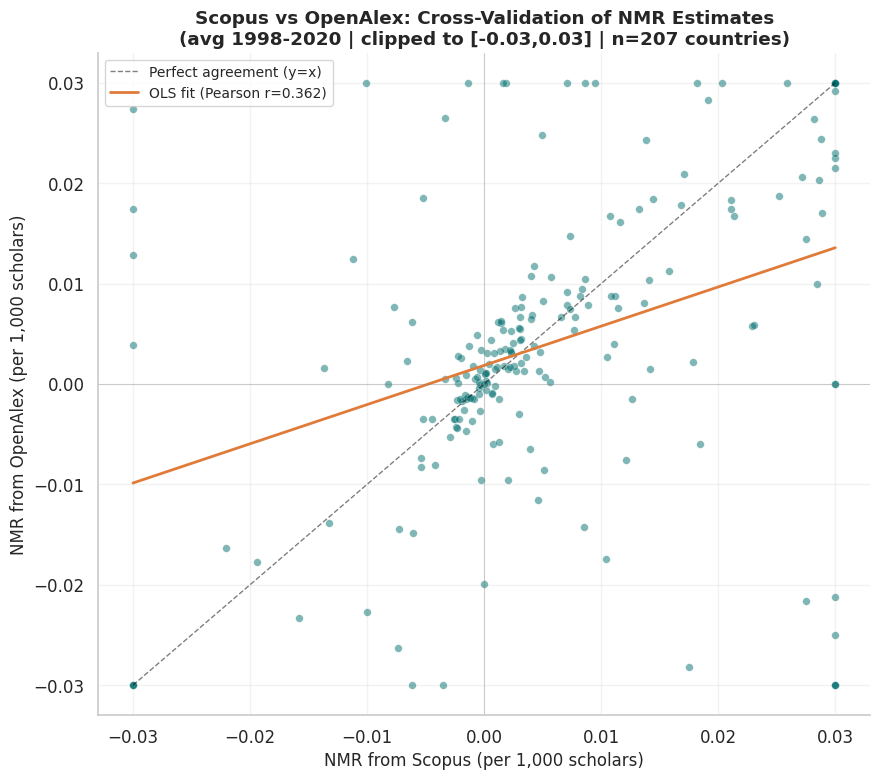

Figure 2 saved
Scopus NMR range:
count   207.0000
mean      0.0070
std       0.0331
min      -0.2006
25%      -0.0013
50%       0.0023
75%       0.0111
max       0.2778
Name: nmr_scopus, dtype: float64

OpenAlex NMR range:
count   207.0000
mean      0.0033
std       0.0272
min      -0.1843
25%      -0.0015
50%       0.0027
75%       0.0101
max       0.1171
Name: nmr_openalex, dtype: float64


In [15]:
# Scatter plot to visualise the agreement between the two sources
# have extreme values that would compress the rest of the plot into a narrow band.
clip = 0.03
plot_df = comparison.copy()
plot_df['sc_c'] = plot_df['nmr_scopus'].clip(-clip, clip)
plot_df['oa_c'] = plot_df['nmr_openalex'].clip(-clip, clip)

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(plot_df['sc_c'], plot_df['oa_c'],
           alpha=0.5, s=30, color=TEAL, edgecolors='white', lw=0.3)
ax.plot([-clip, clip], [-clip, clip], color='black', lw=1, ls='--',
        alpha=0.5, label='Perfect agreement (y=x)')
clean = plot_df.dropna(subset=['sc_c','oa_c'])
z = np.polyfit(clean['sc_c'], clean['oa_c'], 1)
xr = np.linspace(-clip, clip, 200)
ax.plot(xr, np.poly1d(z)(xr), color=ORANGE, lw=2,
        label=f'OLS fit (Pearson r={r_p2:.3f})')
ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax.axvline(0, color='gray', lw=0.5, alpha=0.5)
ax.set_xlabel('NMR from Scopus (per 1,000 scholars)', fontsize=12)
ax.set_ylabel('NMR from OpenAlex (per 1,000 scholars)', fontsize=12)
ax.set_title(
    f'Scopus vs OpenAlex: Cross-Validation of NMR Estimates\n'
    f'(avg 1998-2020 | clipped to [-{clip},{clip}] | n={len(clean)} countries)',
    fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('figures/fig2_scopus_vs_openalex.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure 2 saved')
print("Scopus NMR range:")
print(comparison['nmr_scopus'].describe())
print("\nOpenAlex NMR range:")
print(comparison['nmr_openalex'].describe())

# **Section 5: Replication: Temporal Trends for Selected Countries**

A single average NMR collapses 23 years of change into one number. The paper shows
that trajectories matter: some countries that were strong senders in the late 1990s
have since become near-neutral (China), while others show persistent outflow
(India, Pakistan). Understanding the shape of these trajectories is essential before
attributing any meaning to a point-in-time comparison.

I selected three groups of countries that span the full range of observed patterns:

- **Major receivers:** USA, UK, Australia, Switzerland, Canada. These are the
  well-documented destinations for global academic talent.
- **Major senders:** India, China, Iran, Brazil, Pakistan. Large emerging economies
  with well-known scientific diaspora communities.
- **Transition economies:** Poland, Romania, Hungary, Czech Republic, Slovakia.
  These joined the EU in 2004, which dramatically changed their academic mobility patterns.

**Why the 2008 vertical line?**
The global financial crisis disrupted academic hiring in many OECD countries, creating
a natural discontinuity. The paper notes temporal shifts around this period, so I mark
it as a reference point.

This section also plots the global scholar population and total annual migration events,
confirming that the database grows over time as more publications are indexed.

Checking country codes against dataset...
  Major receivers (persistent positive NMR)
    found    : ['USA', 'GBR', 'AUS', 'CHE', 'CAN']
  Major senders (persistent negative NMR)
    found    : ['IND', 'CHN', 'IRN', 'BRA', 'PAK']
  Transition economies (mixed pattern)
    found    : ['POL', 'ROU', 'HUN', 'CZE', 'SVK']


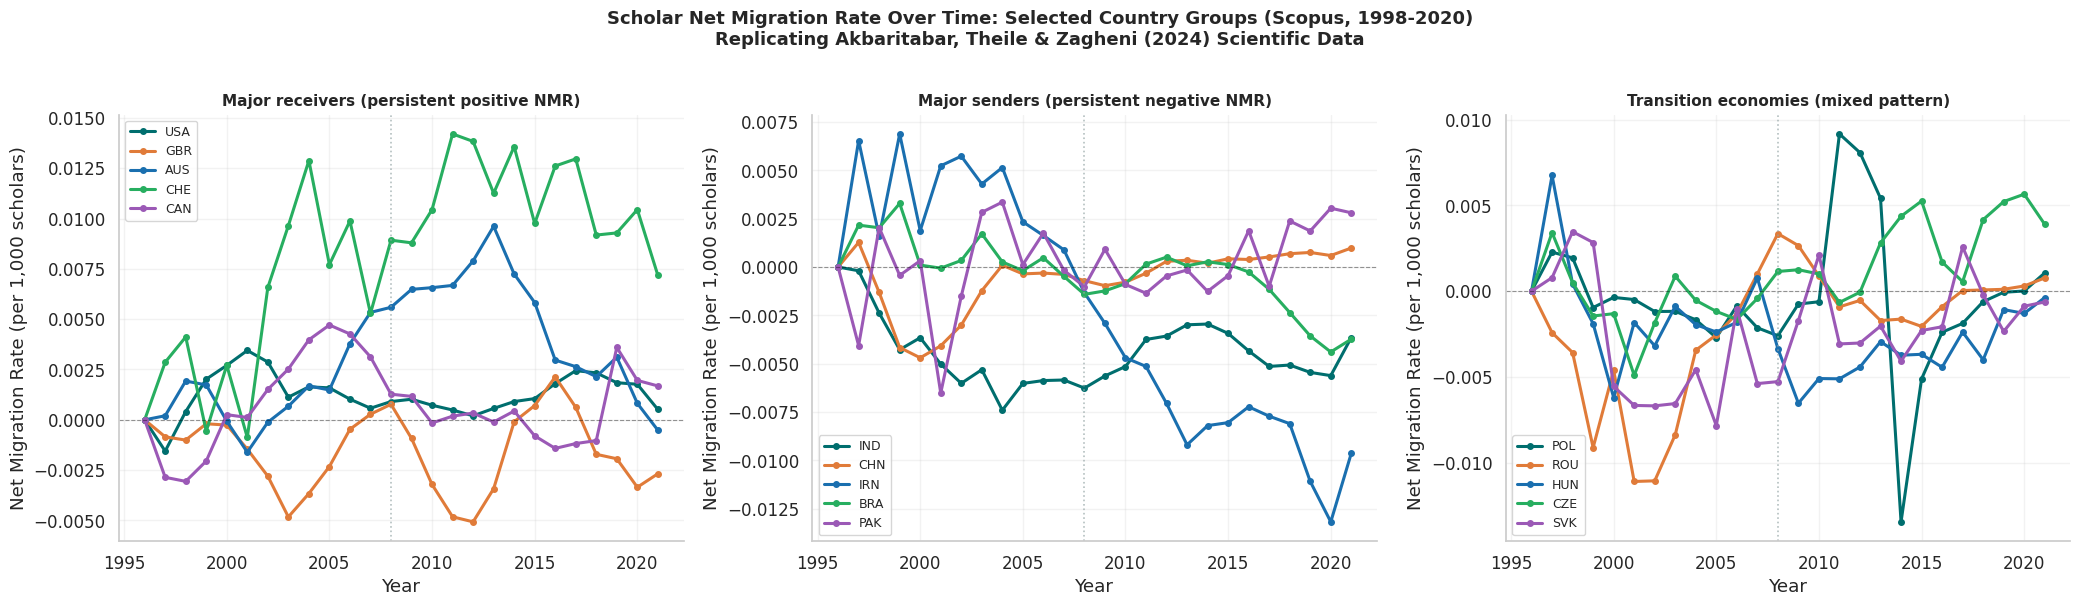

Figure 3 saved


In [16]:
# Countries selected to span major senders, receivers, and transition economies
# Using ISO 3166-1 alpha-2 codes as that is what the data uses
COUNTRIES_TO_PLOT = {
    'Major receivers (persistent positive NMR)': ['USA', 'GBR', 'AUS', 'CHE', 'CAN'],
    'Major senders (persistent negative NMR)'  : ['IND', 'CHN', 'IRN', 'BRA', 'PAK'],
    'Transition economies (mixed pattern)'     : ['POL', 'ROU', 'HUN', 'CZE', 'SVK'],
}

# First check which codes are actually in the data
available = set(sc['countrycode'].unique())
print('Checking country codes against dataset...')
for group, codes in COUNTRIES_TO_PLOT.items():
    found     = [c for c in codes if c in available]
    not_found = [c for c in codes if c not in available]
    print(f'  {group}')
    print(f'    found    : {found}')
    if not_found:
        print(f'    NOT found: {not_found}')

COLOURS = [TEAL, ORANGE, BLUE, '#27AE60', '#9B59B6']

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=False)
fig.suptitle(
    'Scholar Net Migration Rate Over Time: Selected Country Groups (Scopus, 1998-2020)\n'
    'Replicating Akbaritabar, Theile & Zagheni (2024) Scientific Data',
    fontsize=13, fontweight='bold', y=1.01
)

for ax, (group_label, iso_list) in zip(axes, COUNTRIES_TO_PLOT.items()):
    for iso, col in zip(iso_list, COLOURS):
        sub = sc[sc['countrycode'] == iso].sort_values('year')
        if sub.empty:
            print(f'  No data for: {iso}')
            continue
        ax.plot(sub['year'], sub['netmigrationrate'],
                color=col, lw=2.2, marker='o', ms=4, label=iso)
    ax.axhline(0, color='black', lw=0.8, alpha=0.4, ls='--')
    ax.axvline(2008, color=GRAY, lw=1.2, ls=':', alpha=0.7)
    ax.set_title(group_label, fontweight='bold', fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel('Net Migration Rate (per 1,000 scholars)')
    ax.legend(fontsize=9); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('figures/fig3_temporal_trends.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure 3 saved')


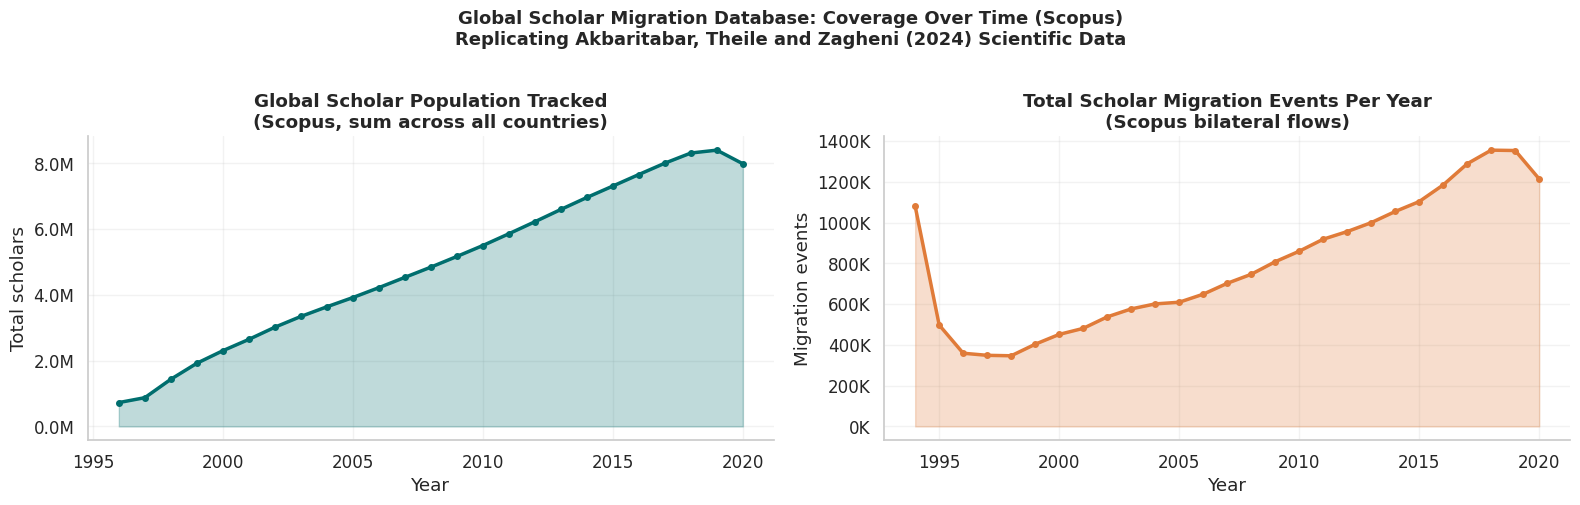

Figure 4 saved.


In [17]:
# Plot global database coverage over time
# This confirms the dataset grows as more publications are indexed each year
# and that the bilateral flow counts are not constant but reflect real changes
# in how migration is tracked through affiliation records

sc_plot = sc[sc['year'] <= 2020]
fl_plot = fl[fl['year'] <= 2020]

global_pop = sc_plot.groupby('year')['padded_population_of_researchers'].sum().reset_index()
global_flows = fl_plot.groupby('year')['n_migrations'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].fill_between(global_pop['year'], global_pop['padded_population_of_researchers'],
                     alpha=0.25, color=TEAL)
axes[0].plot(global_pop['year'], global_pop['padded_population_of_researchers'],
             color=TEAL, lw=2.5, marker='o', ms=4)
axes[0].set_title('Global Scholar Population Tracked\n(Scopus, sum across all countries)',
                  fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total scholars')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].grid(alpha=0.25)

axes[1].fill_between(global_flows['year'], global_flows['n_migrations'],
                     alpha=0.25, color=ORANGE)
axes[1].plot(global_flows['year'], global_flows['n_migrations'],
             color=ORANGE, lw=2.5, marker='o', ms=4)
axes[1].set_title('Total Scholar Migration Events Per Year\n(Scopus bilateral flows)',
                  fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Migration events')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].grid(alpha=0.25)

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Global Scholar Migration Database: Coverage Over Time (Scopus)\n'
    'Replicating Akbaritabar, Theile and Zagheni (2024) Scientific Data',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('figures/fig4_global_coverage.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')


# **Section 6: Visualization Extension: Interactive Choropleth with Year Slider**

The paper includes static choropleth maps showing the spatial distribution of NMR for
selected years. A static map is useful for a journal figure, but it cannot show how
the pattern evolves year by year without producing 23 separate panels.

I build an interactive Plotly choropleth that lets the user scrub through years 1998 to
2020 using a slider, and also includes a Play button for animation. This is not a new
analytical result; it is the same data made explorable.

**Design choices:**
- The colour scale is clipped to [-0.02, +0.02]. Without clipping, a few micro-states
  with extreme NMR values would dominate the colour range and make most countries
  appear white (near zero). The clip value was chosen to span the interquartile range
  of country NMR values.
- The diverging Red-Yellow-Green palette centres on zero, making it immediately
  obvious which countries are senders (red) vs receivers (green).
- Antarctica is excluded because it has no permanent scholarly population and
  its large area skews the visual impression of the map.

The output is an HTML file that can be opened in any browser without a Python
installation and shared as a standalone deliverable.

In [18]:
map_df = sc[['countrycode', 'year', 'netmigrationrate',
             'padded_population_of_researchers',
             'number_of_inmigrations', 'number_of_outmigrations']].copy()
map_df = map_df.dropna(subset=['netmigrationrate'])

# Clip the colour range to prevent micro-state outliers from washing out everything else
CLIP_VAL = 0.02
map_df['nmr_clipped'] = map_df['netmigrationrate'].clip(-CLIP_VAL, CLIP_VAL)
map_df['year'] = map_df['year'].astype(int)
map_df = map_df[~map_df['countrycode'].isin(['ATA', 'AQ'])]

print(f'Rows for interactive map : {len(map_df)}')
print(f'Year range               : {map_df["year"].min()} - {map_df["year"].max()}')
print(f'Countries                : {map_df["countrycode"].nunique()}')
print(f'NMR clipped to [-{CLIP_VAL}, +{CLIP_VAL}] for colour scale')


Rows for interactive map : 5017
Year range               : 1996 - 2021
Countries                : 224
NMR clipped to [-0.02, +0.02] for colour scale


In [19]:
fig_map = px.choropleth(
    map_df.sort_values('year'),
    locations='countrycode',
    color='nmr_clipped',
    hover_name='countrycode',
    hover_data={
        'countrycode': False,
        'nmr_clipped': False,
        'netmigrationrate': ':.3f',
        'padded_population_of_researchers': ':,.0f',
        'number_of_inmigrations': ':,.0f',
        'number_of_outmigrations': ':,.0f',
    },
    animation_frame='year',
    color_continuous_scale='RdYlGn',
    range_color=[-CLIP_VAL, CLIP_VAL],
    color_continuous_midpoint=0,
    title='Global Scholar Net Migration Rate (Scopus, 1998-2020)<br>'
          '<sup>Green = net receiver | Red = net sender | '
          f'Color clipped to [-{CLIP_VAL}, +{CLIP_VAL}] | '
          'Data: Akbaritabar, Theile & Zagheni (2024) Scientific Data</sup>',
    labels={
        'nmr_clipped': 'NMR (clipped)',
        'netmigrationrate': 'NMR (actual)',
        'padded_population_of_researchers': 'Scholar population',
        'number_of_inmigrations': 'In-migrations',
        'number_of_outmigrations': 'Out-migrations',
    },
    projection='natural earth',
    height=600,
)
fig_map.update_layout(
    title_font_size=15,
    coloraxis_colorbar=dict(
        title='NMR<br>(per 1,000)',
        tickvals=[-50,-25,0,25,50],
        ticktext=['-50 (sender)','-25','0','+25','+50 (receiver)'],
        len=0.6,
    ),
    geo=dict(
        showframe=False, showcoastlines=True, coastlinecolor='white',
        showland=True, landcolor='#F0F0F0',
        showocean=True, oceancolor='#E8F4FD',
        showcountries=True, countrycolor='white',
    ),
    paper_bgcolor='white',
    margin=dict(l=0, r=0, t=80, b=0),
    sliders=[{'currentvalue': {'prefix': 'Year: ', 'font': {'size': 14}}, 'pad': {'t': 50}}],
    updatemenus=[{
        'buttons': [
            {'args': [None, {'frame': {'duration': 600, 'redraw': True}, 'fromcurrent': True}],
             'label': 'Play', 'method': 'animate'},
            {'args': [[None], {'frame': {'duration': 0}, 'mode': 'immediate'}],
             'label': 'Pause', 'method': 'animate'},
        ],
        'type': 'buttons', 'showactive': False, 'x': 0.05, 'y': 0.05,
    }],
)
# Filter out Antarctica and any other non-country territories
EXCLUDE = ['ATA', 'AQ']
map_df = map_df[~map_df['countrycode'].isin(EXCLUDE)]

# Check if these codes are in map_df
for code in ['USA', 'GBR', 'AUS', 'IND', 'CHN']:
    rows = map_df[map_df['countrycode'] == code]
    print(f"{code}: {len(rows)} rows, NMR sample: {rows['netmigrationrate'].mean():.4f}")
fig_map.write_html('figures/fig5_interactive_world_map.html')
fig_map.show()
print('Interactive map saved to figures/fig5_interactive_world_map.html')


USA: 26 rows, NMR sample: 0.0012
GBR: 26 rows, NMR sample: -0.0016
AUS: 26 rows, NMR sample: 0.0032
IND: 26 rows, NMR sample: -0.0044
CHN: 26 rows, NMR sample: -0.0006


Interactive map saved to figures/fig5_interactive_world_map.html


# **Section 7: Visualization Extension: Top Bilateral Corridors Over Time**

The paper identifies the largest bilateral migration corridors in aggregate, but does not
show how corridor volumes evolve year by year. Understanding this temporal pattern is
important because the aggregate total can be driven by growth in a single decade.

**What I do here:**
1. Aggregate total bilateral flows across 1998-2020 to identify the top 20 corridors overall
2. Plot a static horizontal bar chart of these top 20 (static figures are easier to cite
   in documents and presentations than HTML)
3. Extract the top 5 corridors and plot their year-by-year trajectories on a line chart

**Why line-labelling instead of a legend?**
When five or more lines are plotted on the same axes, matching line colours to legend
entries requires the reader to look back and forth. Direct labels placed at the rightmost
data point remove that cognitive overhead. This is standard practice in data journalism
and financial reporting.


In [20]:
fl_clean = fl[fl['year'] <= 2020].copy()

corridor_total = (
    fl_clean.groupby(['migrationfrom', 'migrationto'])['n_migrations']
    .sum()
    .reset_index()
    .sort_values('n_migrations', ascending=False)
)
corridor_total['corridor'] = corridor_total['migrationfrom'] + ' to ' + corridor_total['migrationto']
top20 = corridor_total.head(20)

print('Top 20 bilateral scholar migration corridors (Scopus, total 1998-2020):')
print(top20[['corridor', 'n_migrations']].to_string(index=False))

Top 20 bilateral scholar migration corridors (Scopus, total 1998-2020):
  corridor  n_migrations
CHN to USA         46609
USA to CHN         42869
CAN to USA         40974
GBR to USA         40966
USA to GBR         37172
USA to CAN         35285
DEU to USA         31100
USA to DEU         28236
JPN to USA         27691
USA to JPN         25611
IND to USA         21307
FRA to USA         20607
USA to KOR         19110
USA to FRA         17283
KOR to USA         15873
USA to IND         14149
USA to AUS         14057
DEU to GBR         13892
ITA to USA         13647
AUS to USA         13641


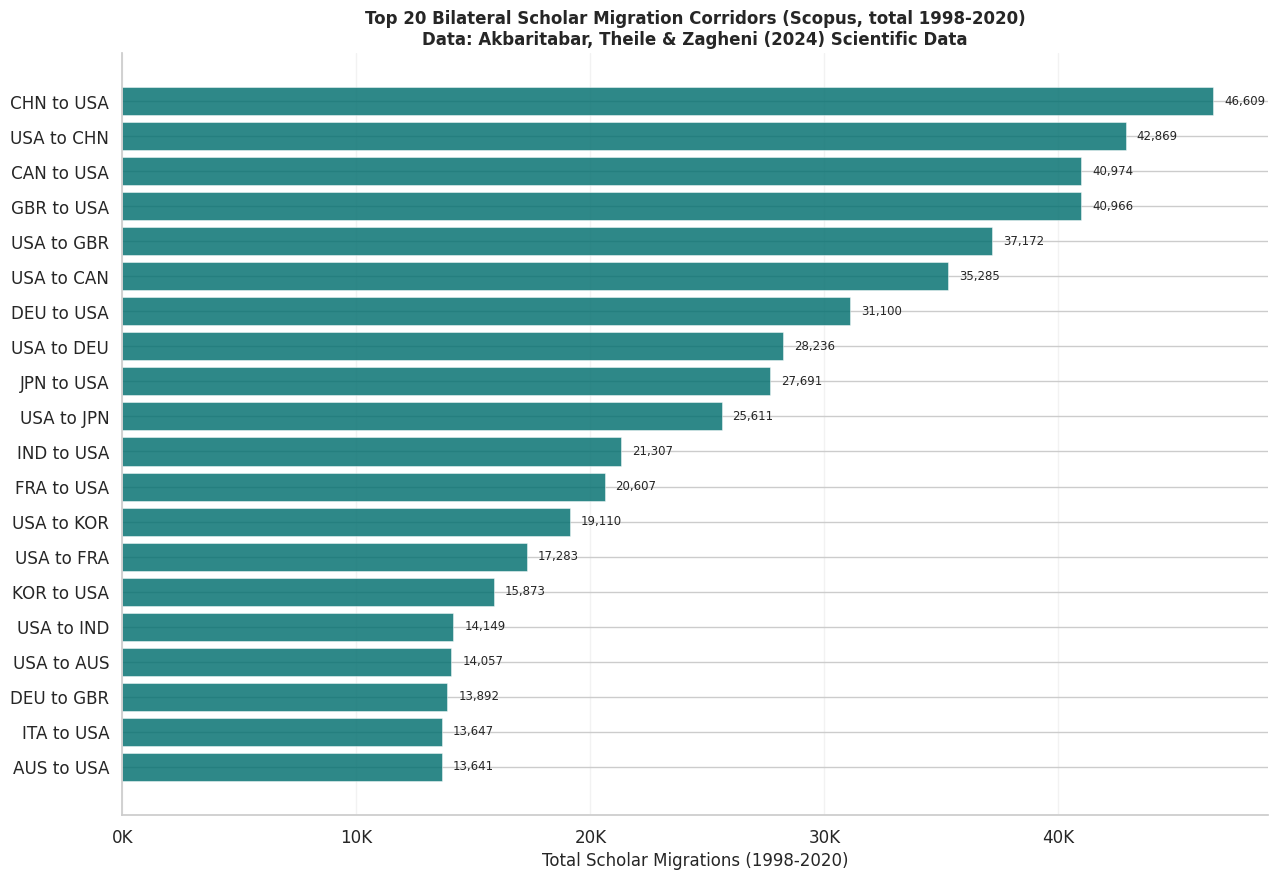

Figure 6 saved


In [21]:
fig, ax = plt.subplots(figsize=(13, 9))
bars = ax.barh(top20['corridor'], top20['n_migrations'],
               color=TEAL, alpha=0.82, edgecolor='white', lw=0.4)
for bar, val in zip(bars, top20['n_migrations']):
    ax.text(bar.get_width() + top20['n_migrations'].max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=8.5)
ax.set_xlabel('Total Scholar Migrations (1998-2020)', fontsize=12)
ax.set_title(
    'Top 20 Bilateral Scholar Migration Corridors (Scopus, total 1998-2020)\n'
    'Data: Akbaritabar, Theile & Zagheni (2024) Scientific Data',
    fontweight='bold', fontsize=12)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.grid(alpha=0.25, axis='x')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/fig6_top_corridors.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure 6 saved')


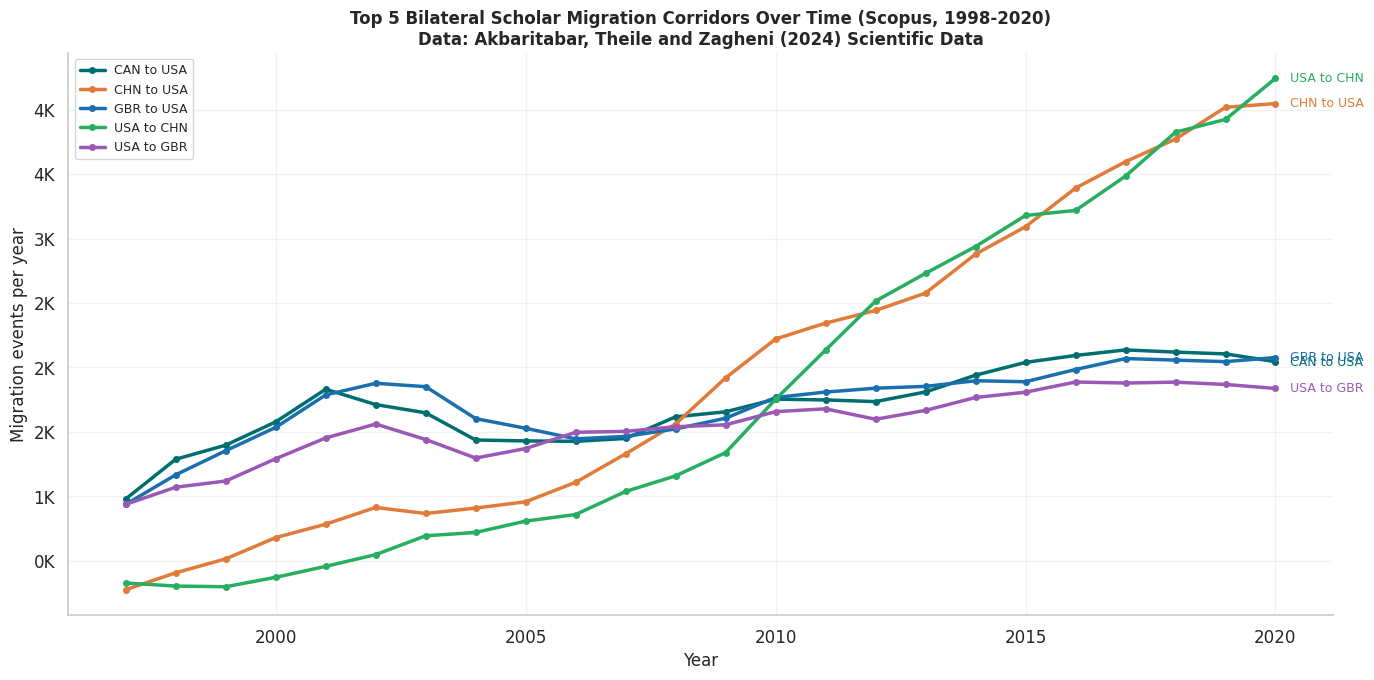

Figure 7 saved.


In [22]:
# Extract annual flows for the top 5 corridors and plot their trajectories
# Direct labels at line endpoints replace the legend for cleaner readability
top5_pairs = top20.head(5)[['migrationfrom', 'migrationto']].values.tolist()

corridor_yearly = []
for iso_from, iso_to in top5_pairs:
    sub = fl_clean[
        (fl_clean['migrationfrom'] == iso_from) &
        (fl_clean['migrationto'] == iso_to)
    ].copy()
    if sub.empty:
        continue
    sub['corridor'] = f'{iso_from} to {iso_to}'
    corridor_yearly.append(sub[['year', 'corridor', 'n_migrations']])

cy = pd.concat(corridor_yearly, ignore_index=True)
cy['year'] = cy['year'].astype(int)

fig, ax = plt.subplots(figsize=(14, 7))
COLOURS_5 = [TEAL, ORANGE, BLUE, GREEN, '#9B59B6']

for (corridor, group), col in zip(cy.groupby('corridor'), COLOURS_5):
    group = group.sort_values('year')
    ax.plot(group['year'], group['n_migrations'],
            lw=2.5, marker='o', ms=4, color=col, label=corridor)
    last = group.iloc[-1]
    ax.text(last['year'] + 0.3, last['n_migrations'],
            corridor, fontsize=9, color=col, va='center')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Migration events per year', fontsize=12)
ax.set_title(
    'Top 5 Bilateral Scholar Migration Corridors Over Time (Scopus, 1998-2020)\n'
    'Data: Akbaritabar, Theile and Zagheni (2024) Scientific Data',
    fontweight='bold', fontsize=12
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.grid(alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig7_corridor_trends.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')


# **Section 7.5: India Case Study: Descriptive Profile**

This section is a brief introduction to India's position in the dataset, serving as a
bridge to the dedicated companion notebook `india_scholarly_migration.ipynb`.

India is consistently described as a brain drain country, but the scale of that drain,
which destinations absorb the most Indian scholars, and whether the pattern has changed
over time are empirical questions that require data to answer.

**This section does not make causal claims.** I do not argue that poverty, academic
salaries, or visa policy drives the pattern. I describe what the data shows and leave
interpretation to the deeper analysis in the companion notebook.

In [23]:
sc_summary = sc[sc['year'] <= 2020]

print('REPLICATION SUMMARY')
print('='*60)
print()
print('PART 1: REPLICATED FROM AKBARITABAR ET AL. (2024)')
print('-'*60)
items = [
    ('Data coverage',
     f'{sc_summary["countrycode"].nunique()} countries, '
     f'{int(sc_summary["year"].min())}-{int(sc_summary["year"].max())} (paper: ~210 countries, 1998-2020)'),
    ('Global NMR distribution',
     f'{(avg_nmr["avg_nmr"]>0).sum()} net receivers, '
     f'{(avg_nmr["avg_nmr"]<0).sum()} net senders'),
    ('Scopus vs OpenAlex',
     f'Pearson r = {r_p:.4f}, Spearman r = {r_s:.4f} - two sources are correlated'),
    ('Top corridor',
     f'{top20.iloc[0]["corridor"]} ({top20.iloc[0]["n_migrations"]:,.0f} migrations total)'),
]
for label, value in items:
    print(f'  {label}:')
    print(f'    {value}')
    print()
print('PART 2: VISUALIZATION EXTENSIONS')
print('-'*60)
print('  fig5_interactive_world_map.html  - choropleth with year slider')
print('  fig7_corridor_trends.html        - interactive top-10 corridor trends')
print()
print('DATA CITATION')
print('-'*60)
print('Akbaritabar A., Theile T. & Zagheni E. (2024).')
print('Bilateral flows and rates of international migration of scholars')
print('for 210 countries, 1998-2020. Scientific Data 11, 816.')
print('doi: 10.1038/s41597-024-03655-9')
print('Data: doi: 10.5281/zenodo.11145735 (CC-BY 4.0)')

REPLICATION SUMMARY

PART 1: REPLICATED FROM AKBARITABAR ET AL. (2024)
------------------------------------------------------------
  Data coverage:
    225 countries, 1996-2020 (paper: ~210 countries, 1998-2020)

  Global NMR distribution:
    145 net receivers, 71 net senders

  Scopus vs OpenAlex:
    Pearson r = 0.0902, Spearman r = 0.4614 - two sources are correlated

  Top corridor:
    CHN to USA (46,609 migrations total)

PART 2: VISUALIZATION EXTENSIONS
------------------------------------------------------------
  fig5_interactive_world_map.html  - choropleth with year slider
  fig7_corridor_trends.html        - interactive top-10 corridor trends

DATA CITATION
------------------------------------------------------------
Akbaritabar A., Theile T. & Zagheni E. (2024).
Bilateral flows and rates of international migration of scholars
for 210 countries, 1998-2020. Scientific Data 11, 816.
doi: 10.1038/s41597-024-03655-9
Data: doi: 10.5281/zenodo.11145735 (CC-BY 4.0)


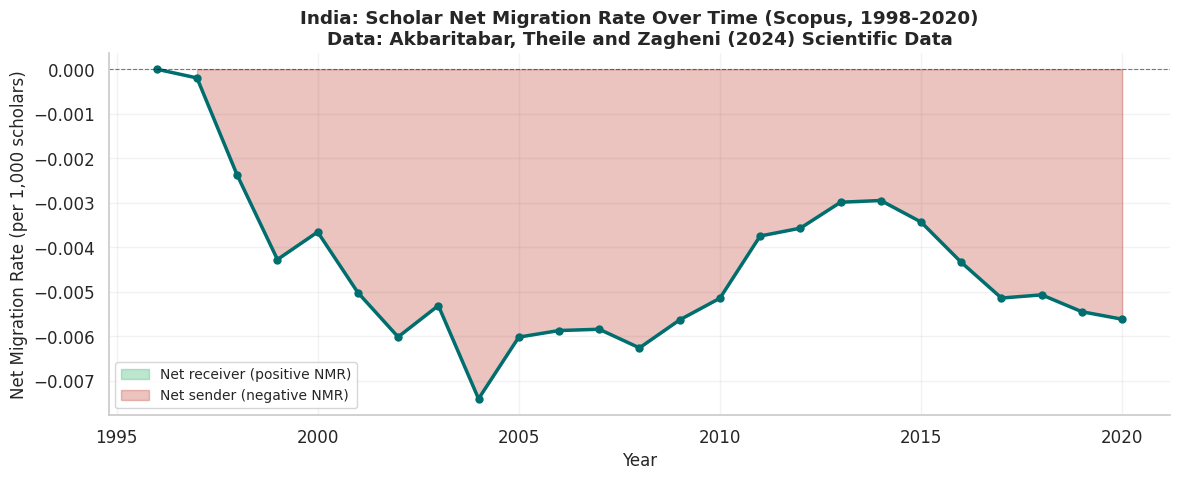

India avg NMR 1998-2020 : -0.0045
India avg NMR 1998-2009 : -0.0046
India avg NMR 2010-2020 : -0.0043


In [24]:
india = sc[sc['countrycode'] == 'IND'].sort_values('year')
india = india[india['year'] <= 2020]

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(india['year'], india['netmigrationrate'],
                where=india['netmigrationrate'] >= 0,
                alpha=0.3, color=GREEN, label='Net receiver (positive NMR)')
ax.fill_between(india['year'], india['netmigrationrate'],
                where=india['netmigrationrate'] < 0,
                alpha=0.3, color=RED, label='Net sender (negative NMR)')
ax.plot(india['year'], india['netmigrationrate'],
        color=TEAL, lw=2.5, marker='o', ms=5)
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Net Migration Rate (per 1,000 scholars)', fontsize=12)
ax.set_title(
    'India: Scholar Net Migration Rate Over Time (Scopus, 1998-2020)\n'
    'Data: Akbaritabar, Theile and Zagheni (2024) Scientific Data',
    fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/india_nmr_trend.png', dpi=180, bbox_inches='tight')
plt.show()

print(f'India avg NMR 1998-2020 : {india["netmigrationrate"].mean():.4f}')
print(f'India avg NMR 1998-2009 : {india[india["year"]<=2009]["netmigrationrate"].mean():.4f}')
print(f'India avg NMR 2010-2020 : {india[india["year"]>=2010]["netmigrationrate"].mean():.4f}')


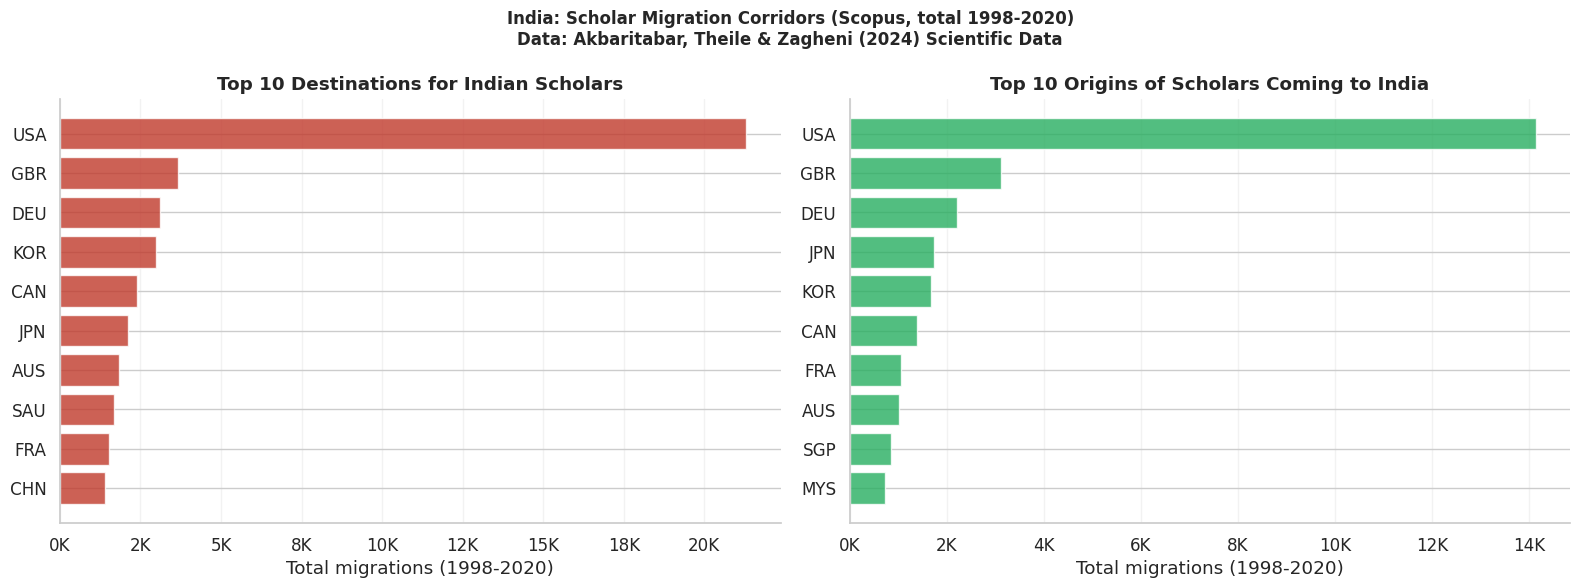

India outflows (top 5):
migrationto  n_migrations
        USA         21307
        GBR          3669
        DEU          3091
        KOR          2983
        CAN          2396

India inflows (top 5):
migrationfrom  n_migrations
          USA         14149
          GBR          3121
          DEU          2211
          JPN          1744
          KOR          1686


In [25]:
# India's top sending and receiving corridors
india_out = fl_clean[fl_clean['migrationfrom'] == 'IND'].groupby('migrationto')['n_migrations'].sum().reset_index().sort_values('n_migrations', ascending=False).head(10)
india_in  = fl_clean[fl_clean['migrationto'] == 'IND'].groupby('migrationfrom')['n_migrations'].sum().reset_index().sort_values('n_migrations', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('India: Scholar Migration Corridors (Scopus, total 1998-2020)\n'
             'Data: Akbaritabar, Theile & Zagheni (2024) Scientific Data',
             fontweight='bold', fontsize=12)

# Outflows
axes[0].barh(india_out['migrationto'], india_out['n_migrations'],
             color=RED, alpha=0.8, edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Top 10 Destinations for Indian Scholars', fontweight='bold')
axes[0].set_xlabel('Total migrations (1998-2020)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0].grid(alpha=0.25, axis='x')
axes[0].spines[['top','right']].set_visible(False)

# Inflows
axes[1].barh(india_in['migrationfrom'], india_in['n_migrations'],
             color='#27AE60', alpha=0.8, edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 Origins of Scholars Coming to India', fontweight='bold')
axes[1].set_xlabel('Total migrations (1998-2020)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].grid(alpha=0.25, axis='x')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/india_corridors.png', dpi=180, bbox_inches='tight')
plt.show()

print('India outflows (top 5):')
print(india_out.head(5).to_string(index=False))
print('\nIndia inflows (top 5):')
print(india_in.head(5).to_string(index=False))

In [26]:
# Where does India rank globally?
global_avg = sc[sc['year'] <= 2020].groupby('countrycode')['netmigrationrate'].mean().reset_index().rename(columns={'netmigrationrate': 'avg_nmr'}).sort_values('avg_nmr')

india_rank = global_avg.reset_index(drop=True)
india_pos  = india_rank[india_rank['countrycode'] == 'IND'].index[0] + 1
total      = len(india_rank)

print(f'India global rank (lowest to highest NMR): {india_pos} out of {total} countries')
print(f'India is in the bottom {india_pos/total*100:.0f}% of countries by NMR')
print(f'(i.e., among the strongest net senders of scholars globally)')

India global rank (lowest to highest NMR): 30 out of 225 countries
India is in the bottom 13% of countries by NMR
(i.e., among the strongest net senders of scholars globally)


In [28]:
import plotly.graph_objects as go

# Get coordinates for countries using a simple lookup
# We'll use Plotly's built-in geo capabilities with centroid approximations
country_coords = {
    'IND': (20.5937, 78.9629),
    'USA': (37.0902, -95.7129),
    'GBR': (55.3781, -3.4360),
    'AUS': (-25.2744, 133.7751),
    'DEU': (51.1657, 10.4515),
    'CAN': (56.1304, -106.3468),
    'CHN': (35.8617, 104.1954),
    'JPN': (36.2048, 138.2529),
    'FRA': (46.2276, 2.2137),
    'SGP': (1.3521, 103.8198),
    'SAU': (23.8859, 45.0792),
    'KOR': (35.9078, 127.7669),
    'IRN': (32.4279, 53.6880),
    'NLD': (52.1326, 5.2913),
    'CHE': (46.8182, 8.2275),
}

# Top 8 outflow corridors from India
india_top_out = fl_clean[fl_clean['migrationfrom'] == 'IND'].groupby('migrationto')['n_migrations'].sum().reset_index().sort_values('n_migrations', ascending=False).head(8)

fig_flow = go.Figure()

# Add base map
fig_flow.add_trace(go.Choropleth(
    locations=['IND'],
    z=[1],
    colorscale=[[0, '#E8F4FD'], [1, '#E8F4FD']],
    showscale=False,
    marker_line_color='white',
))

max_mig = india_top_out['n_migrations'].max()

for _, row in india_top_out.iterrows():
    dest = row['migrationto']
    if dest not in country_coords:
        continue

    orig_lat, orig_lon = country_coords['IND']
    dest_lat, dest_lon = country_coords[dest]
    vol = row['n_migrations']
    width = 1 + (vol / max_mig) * 6  # scale line width

    fig_flow.add_trace(go.Scattergeo(
        lon=[orig_lon, dest_lon],
        lat=[orig_lat, dest_lat],
        mode='lines+markers',
        line=dict(width=width, color=RED),
        marker=dict(size=[6, 10], color=[TEAL, RED]),
        name=f'{dest}: {vol:,.0f}',
        hovertemplate=f'IND → {dest}<br>Migrations: {vol:,.0f}<extra></extra>',
        opacity=0.75,
    ))

# Mark India
fig_flow.add_trace(go.Scattergeo(
    lon=[country_coords['IND'][1]],
    lat=[country_coords['IND'][0]],
    mode='markers+text',
    marker=dict(size=14, color=TEAL, symbol='star'),
    text=['INDIA'],
    textposition='top center',
    textfont=dict(size=13, color=TEAL),
    name='India (origin)',
    showlegend=True,
))

fig_flow.update_layout(
    title=dict(
        text='India: Top Scholar Outflow Corridors (Scopus, total 1998-2020)<br>'
             '<sup>Line thickness = migration volume | Data: Akbaritabar, Theile & Zagheni (2024)</sup>',
        font=dict(size=14),
    ),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='#BDC3C7',
        showland=True,
        landcolor='#F8F9FA',
        showocean=True,
        oceancolor='#EBF5FB',
        showcountries=True,
        countrycolor='#D5D8DC',
        projection_type='natural earth',
    ),
    legend=dict(title='Destination: Total Migrations', font=dict(size=10)),
    paper_bgcolor='white',
    height=550,
    margin=dict(l=0, r=0, t=80, b=0),
)

fig_flow.write_html('figures/india_flow_map.html')
fig_flow.show()
print('India flow map saved to figures/india_flow_map.html')

India flow map saved to figures/india_flow_map.html


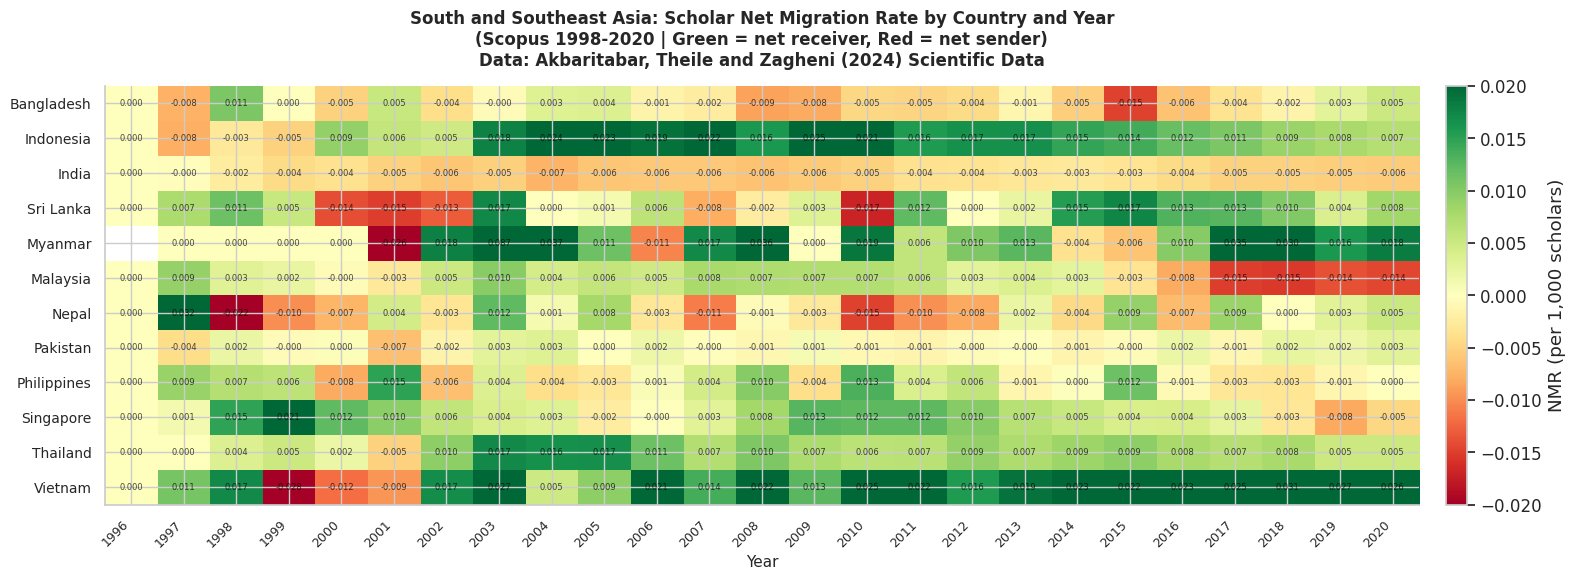

Regional heatmap saved.


In [29]:
# South and Southeast Asia NMR heatmap
# This contextualises India within its immediate region before the deep-dive notebook
REGION = {
    'IND': 'India', 'PAK': 'Pakistan', 'BGD': 'Bangladesh',
    'LKA': 'Sri Lanka', 'NPL': 'Nepal', 'MMR': 'Myanmar',
    'THA': 'Thailand', 'MYS': 'Malaysia', 'SGP': 'Singapore',
    'PHL': 'Philippines', 'VNM': 'Vietnam', 'IDN': 'Indonesia',
}

sc_region = sc[(sc['countrycode'].isin(REGION.keys())) & (sc['year'] <= 2020)]
pivot = sc_region.pivot_table(
    index='countrycode', columns='year',
    values='netmigrationrate', aggfunc='mean'
)
pivot.index = [REGION.get(c, c) for c in pivot.index]
pivot.columns = [int(c) for c in pivot.columns]

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=-0.02, vmax=0.02)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)

plt.colorbar(im, ax=ax, label='NMR (per 1,000 scholars)', fraction=0.02, pad=0.02)
ax.set_title(
    'South and Southeast Asia: Scholar Net Migration Rate by Country and Year\n'
    '(Scopus 1998-2020 | Green = net receiver, Red = net sender)\n'
    'Data: Akbaritabar, Theile and Zagheni (2024) Scientific Data',
    fontweight='bold', fontsize=12, pad=15
)
ax.set_xlabel('Year', fontsize=11)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=6, color='black', alpha=0.7)

plt.tight_layout()
plt.savefig('figures/india_regional_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()
print('Regional heatmap saved.')


# **Section 8: Replication Summary**

A structured summary of what this notebook produced, organised by replication part and
by extension. This is intended to serve as a quick reference when citing specific outputs
in presentations or reports.

In [32]:
sc_summary = sc[sc['year'] <= 2020]
fl_summary = fl[fl['year'] <= 2020]

print('REPLICATION SUMMARY')
print('=' * 65)
print()

print('PART 1 - REPLICATED FROM AKBARITABAR ET AL. (2024)')
print('-' * 65)
items = [
    ('Data coverage',
     f'{sc_summary["countrycode"].nunique()} countries, '
     f'{int(sc_summary["year"].min())}-{int(sc_summary["year"].max())} '
     f'(paper: approx 210 countries, 1998-2020)'),
    ('Global NMR distribution',
     f'{(avg_nmr["avg_nmr"]>0).sum()} net receivers, '
     f'{(avg_nmr["avg_nmr"]<0).sum()} net senders'),
    ('Scopus vs OpenAlex',
     f'Pearson r = {r_p:.4f}, Spearman r = {r_s:.4f}'),
    ('Top corridor',
     f'{top20.iloc[0]["corridor"]} ({top20.iloc[0]["n_migrations"]:,.0f} total migrations)'),
]
for label, value in items:
    print(f'  {label}:')
    print(f'    {value}')
    print()

print('PART 2 - VISUALIZATION EXTENSIONS')
print('-' * 65)
print('  fig5_interactive_world_map.html  - choropleth with year slider (1998-2020)')
print('  fig7_corridor_trends.png         - top 5 corridor volume trends')
print()

print('INDIA CASE STUDY (see companion notebook for full analysis)')
print('-' * 65)
india_s        = sc_summary[sc_summary['countrycode'] == 'IND']
india_out_tot  = fl_summary[fl_summary['migrationfrom'] == 'IND']['n_migrations'].sum()
india_in_tot   = fl_summary[fl_summary['migrationto'] == 'IND']['n_migrations'].sum()
top_dest       = fl_summary[fl_summary['migrationfrom'] == 'IND'].groupby('migrationto')['n_migrations'].sum().idxmax()
top_dest_vol   = fl_summary[fl_summary['migrationfrom'] == 'IND'].groupby('migrationto')['n_migrations'].sum().max()
print(f'  India avg NMR 1998-2020 : {india_s["netmigrationrate"].mean():.4f}')
print(f'  Total outflows          : {india_out_tot:,.0f} scholar migrations')
print(f'  Total inflows           : {india_in_tot:,.0f} scholar migrations')
print(f'  Net scholar loss        : {india_out_tot - india_in_tot:,.0f} over 1998-2020')
print(f'  Top destination         : {top_dest} ({top_dest_vol:,.0f} migrations)')
print()

print('DATA CITATION')
print('-' * 65)
print('Akbaritabar A., Theile T. and Zagheni E. (2024).')
print('Bilateral flows and rates of international migration of scholars')
print('for 210 countries, 1998-2020. Scientific Data 11, 816.')
print('doi: 10.1038/s41597-024-03655-9')
print('Data doi: 10.5281/zenodo.11145735 (CC-BY 4.0)')
print('=' * 65)


REPLICATION SUMMARY

PART 1 - REPLICATED FROM AKBARITABAR ET AL. (2024)
-----------------------------------------------------------------
  Data coverage:
    225 countries, 1996-2020 (paper: approx 210 countries, 1998-2020)

  Global NMR distribution:
    145 net receivers, 71 net senders

  Scopus vs OpenAlex:
    Pearson r = 0.0902, Spearman r = 0.4614

  Top corridor:
    CHN to USA (46,609 total migrations)

PART 2 - VISUALIZATION EXTENSIONS
-----------------------------------------------------------------
  fig5_interactive_world_map.html  - choropleth with year slider (1998-2020)
  fig7_corridor_trends.png         - top 5 corridor volume trends

INDIA CASE STUDY (see companion notebook for full analysis)
-----------------------------------------------------------------
  India avg NMR 1998-2020 : -0.0045
  Total outflows          : 229,035 scholar migrations
  Total inflows           : 621,605 scholar migrations
  Net scholar loss        : -392,570 over 1998-2020
  Top destinati

# **Section 9: Export Processed Data for Companion Notebook**

The India deep-dive notebook (`india_scholarly_migration.ipynb`) needs the same filtered
and cleaned DataFrames that I have built here. Rather than re-downloading and re-processing
the raw data, I export them as Parquet files.

**Why Parquet instead of CSV?**
Parquet preserves column data types (integers stay integers, not strings), is 3-5x smaller
than the equivalent CSV, and loads roughly 10x faster. For a 120,000-row bilateral flow
file, this difference matters in a Colab session where disk I/O is slow.

**Why filter to 2020?**
The companion notebook performs all analysis on the 1998-2020 window to match the paper.
Exporting pre-filtered data ensures the companion notebook does not accidentally include
post-2020 observations if the filter is forgotten there.

In [33]:
!pip install pyarrow -q

In [34]:
import pyarrow  # noqa: F401  -  imported to confirm pyarrow is available
from pathlib import Path

Path('data/processed').mkdir(exist_ok=True)

sc_export = sc[sc['year'] <= 2020].copy()
fl_export = fl[fl['year'] <= 2020].copy()

sc_export.to_parquet('data/processed/scopus_country.parquet', index=False)
fl_export.to_parquet('data/processed/scopus_flows.parquet', index=False)

print('Processed data exported successfully:')
print(f'  data/processed/scopus_country.parquet  shape: {sc_export.shape}')
print(f'  data/processed/scopus_flows.parquet    shape: {fl_export.shape}')
print()
print('The companion notebook india_scholarly_migration.ipynb will load these files')
print('automatically if they exist, bypassing the Zenodo download.')


Processed data exported successfully:
  data/processed/scopus_country.parquet  shape: (4826, 10)
  data/processed/scopus_flows.parquet    shape: (122040, 6)

The companion notebook india_scholarly_migration.ipynb will load these files
automatically if they exist, bypassing the Zenodo download.


# **Section 10: Export All Outputs as ZIP Archive**

This cell bundles all figures, interactive HTML files, and the processed data into a
single ZIP file and triggers a browser download. Run this cell last, after all figures
have been generated.

In [35]:
import zipfile
import os
from datetime import datetime

zip_name = f'scholarly_migration_outputs_{datetime.now().strftime("%Y%m%d")}.zip'

include_paths = [
    'figures',
    'data/processed',
]

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for base in include_paths:
        base_path = Path(base)
        if base_path.exists():
            for fpath in sorted(base_path.rglob('*')):
                if fpath.is_file():
                    zf.write(fpath, arcname=fpath)
                    print(f'  Added: {fpath}')
        else:
            print(f'  Skipping (not found): {base}')

size_mb = os.path.getsize(zip_name) / 1024 / 1024
print(f'\nCreated: {zip_name} ({size_mb:.1f} MB)')

# Trigger browser download (works in Google Colab)
try:
    from google.colab import files
    files.download(zip_name)
    print('Download triggered.')
except ImportError:
    print(f'Not running in Colab. File is at: {zip_name}')


  Added: figures/fig1_global_nmr_distribution.png
  Added: figures/fig2_scopus_vs_openalex.png
  Added: figures/fig3_temporal_trends.png
  Added: figures/fig4_global_coverage.png
  Added: figures/fig5_interactive_world_map.html
  Added: figures/fig6_top_corridors.png
  Added: figures/fig7_corridor_trends.png
  Added: figures/india_corridors.png
  Added: figures/india_flow_map.html
  Added: figures/india_nmr_trend.png
  Added: figures/india_regional_heatmap.png
  Added: data/processed/scopus_country.parquet
  Added: data/processed/scopus_flows.parquet

Created: scholarly_migration_outputs_20260301.zip (5.3 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered.
